# SHAP Heatmap Plot

This notebook demonstrates how to use `shap.plots.heatmap` to visualize SHAP explanations across many samples simultaneously. It uses an XGBoost classifier trained on the UCI Adult Income dataset — a binary classification task predicting whether an individual earned more than $50,000 per year.

## Model Training

We begin by loading the dataset and training an XGBoost classifier. A fixed random seed is set to ensure reproducibility.

In [1]:
import numpy as np
import xgboost
import shap

# Set random seed for reproducibility
np.random.seed(0)

# Load dataset
X, y = shap.datasets.adult()

# Train XGBoost classifier with fixed random state
model = xgboost.XGBClassifier(
    n_estimators=100,
    max_depth=2,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=0
).fit(X, y)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:30:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## SHAP Explanation

`shap.Explainer` automatically selects the most appropriate explanation algorithm for the given model. Here it will use `TreeExplainer` for XGBoost. We compute SHAP values for the first 1,000 samples to keep the visualisation manageable.

The resulting `shap_values` object is an `Explanation` with shape `(n_samples, n_features)`. Each value quantifies how much a given feature pushed the model output above or below the base value (expected model output) for that sample.

In [2]:
# Use shap.Explainer — automatically selects TreeExplainer for XGBoost
explainer = shap.Explainer(model, X)

# Compute SHAP values for the first 1,000 samples
shap_values = explainer(X[:1000])

## Visualization

The heatmap plot encodes SHAP values as colours across a grid where:
- **x-axis** — individual samples (instances)
- **y-axis** — model input features, ranked by global importance
- **top panel** — the model output for each sample (centred on the base value)
- **right bar chart** — overall feature importance (`shap.Explanation.abs.mean(0)` by default)

### Default plot

By default, samples are ordered using hierarchical clustering (`shap.order.hclust`), which groups together samples that share similar explanations. This makes patterns — such as the strong positive effect of `capital-gain` on income predictions — visually apparent.

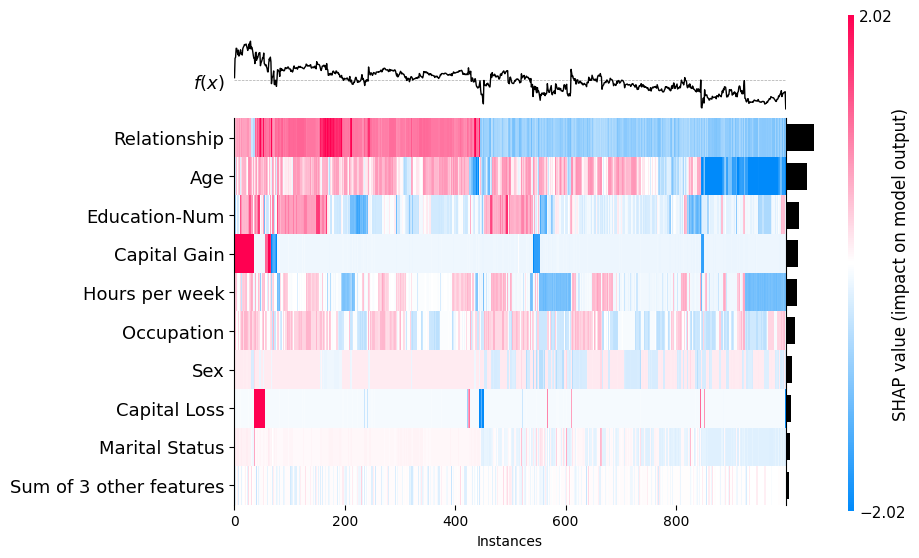

<Axes: xlabel='Instances'>

In [3]:
shap.plots.heatmap(shap_values)

### Showing more features with `max_display`

By default only the top 10 features are shown. Increase `max_display` to reveal additional features. Here we show the top 12.

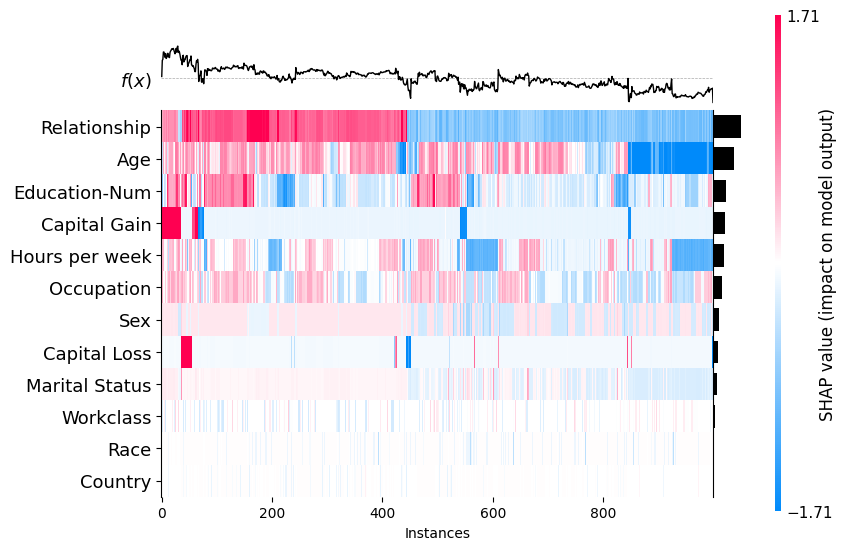

<Axes: xlabel='Instances'>

In [4]:
shap.plots.heatmap(shap_values, max_display=12)

### Changing feature ranking with `feature_values`

The `feature_values` parameter controls both the ranking of features on the y-axis and the height of bars in the right-hand importance chart. The default is `shap.Explanation.abs.mean(0)` (mean absolute SHAP value). Below we instead sort by the **maximum absolute SHAP value** across all samples, which highlights features that have a large impact on at least one prediction.

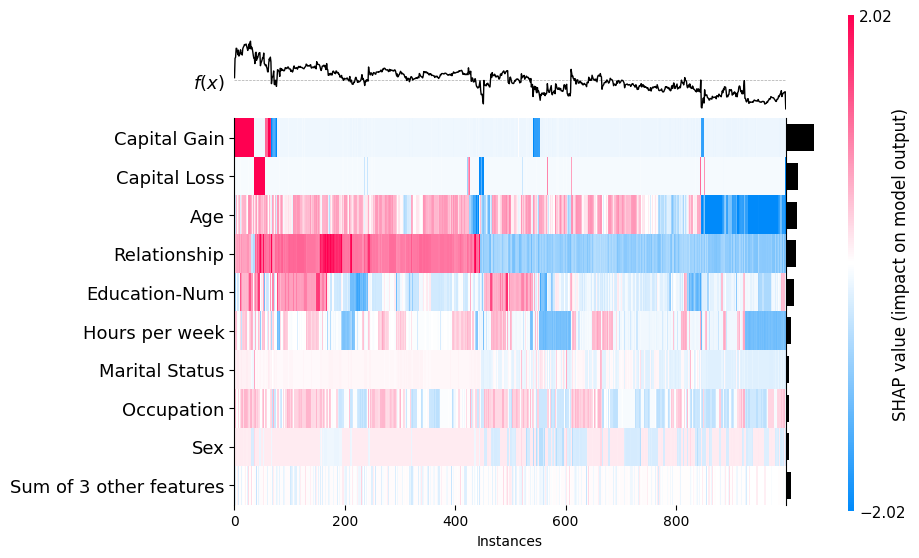

<Axes: xlabel='Instances'>

In [5]:
shap.plots.heatmap(shap_values, feature_values=shap_values.abs.max(0))

### Changing sample ordering with `instance_order`

The `instance_order` parameter controls the left-to-right ordering of samples on the x-axis. The default hierarchical clustering groups structurally similar explanations together. Sorting by the **sum of SHAP values** instead arranges samples from most negative to most positive predicted effect, providing a complementary view of how feature contributions accumulate.

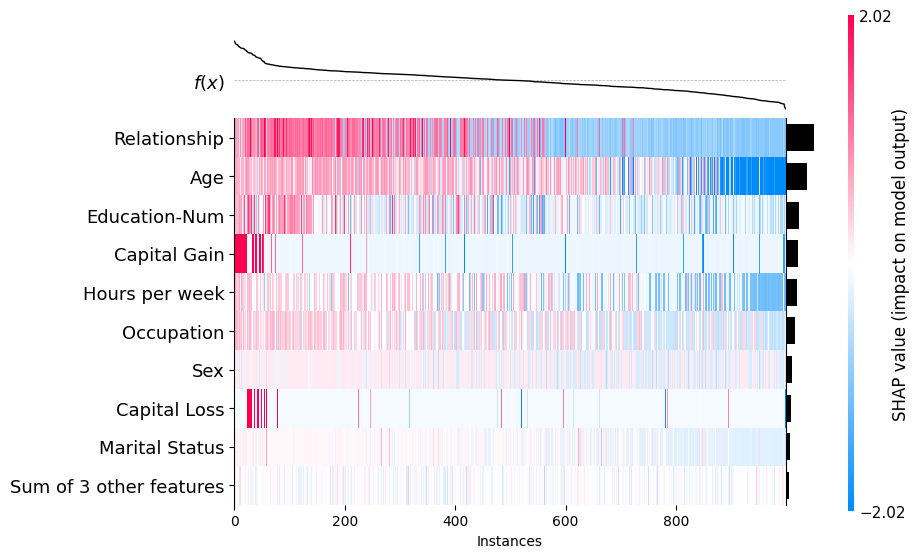

<Axes: xlabel='Instances'>

In [6]:
shap.plots.heatmap(shap_values, instance_order=shap_values.sum(1))

<hr>
This example demonstrates how heatmaps provide a global view of model behavior by revealing patterns in feature contributions across many samples.